In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score
import tensorflow as tf

In [2]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from sklearn.model_selection import train_test_split

In [3]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 10s 1us/step


In [4]:
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

In [5]:
print("x_train [shape %s] sample patch:\n" % (str(x_train.shape)), x_train[1, 15:20, 5:10])

x_train [shape (48000, 28, 28)] sample patch:
 [[  0  77 254 154   0]
 [  0 145 253  96   0]
 [  0 254 238  37   0]
 [  0 254 229   0   0]
 [  0 254 246  69   0]]


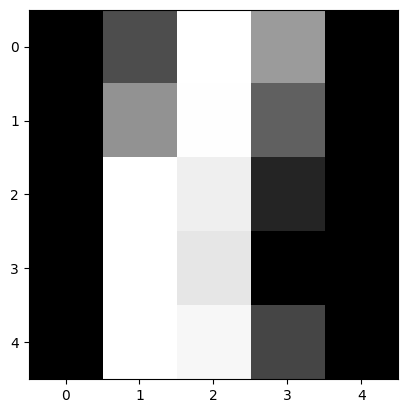

In [6]:
import matplotlib.pyplot as plt
plt.imshow(x_train[1, 15:20, 5:10], cmap='gray')
plt.show()


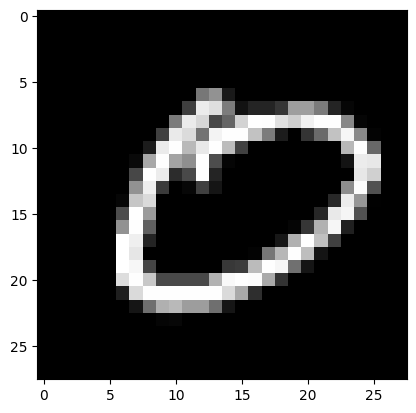

In [7]:
import matplotlib.pyplot as plt
plt.imshow(x_train[1], cmap='gray')
plt.show()


In [8]:
x_train = x_train.astype('float32')/255.0
x_val = x_val.astype('float32')/255.0

In [9]:
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)
y_train_oh = tf.keras.utils.to_categorical(y_train, 10)
y_val_oh = tf.keras.utils.to_categorical(y_val, 10)

In [10]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(500, activation='sigmoid', input_shape=(784,)),
    tf.keras.layers.Dense(128, activation='sigmoid'),
    tf.keras.layers.Dense(10, activation='softmax')
])


c:\Users\Ahmed Morad\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 500)            │       392,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        64,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 457,918 (1.75 MB)

 Trainable params: 457,918 (1.75 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [14]:
history = model.fit(x_train, y_train_oh, batch_size=32, epochs=10, validation_split=0.2)
import keras
y_test_oh = keras.utils.to_categorical(y_test)
test_loss, test_acc = model.evaluate(x_test, y_test_oh)
print('Test accuracy:', test_acc)

Epoch 1/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.9960 - loss: 0.0137 - val_accuracy: 0.9747 - val_loss: 0.0880
Epoch 2/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9971 - loss: 0.0105 - val_accuracy: 0.9750 - val_loss: 0.0877
Epoch 3/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9977 - loss: 0.0079 - val_accuracy: 0.9775 - val_loss: 0.0892
Epoch 4/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9980 - loss: 0.0070 - val_accuracy: 0.9782 - val_loss: 0.0941
Epoch 5/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9980 - loss: 0.0068 - val_accuracy: 0.9757 - val_loss: 0.0958
Epoch 6/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9986 - loss: 0.0044 - val_accuracy: 0.9777 - val_loss: 0.0969
Epoch 7/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9985 - loss: 0.0053 - val_accuracy: 0.9778 - val_loss: 0.1021
Epoch 8/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9992 - loss: 0.00

In [15]:
def get_random_indices(total_images, num_images):
    return np.random.choice(total_images, num_images, replace=False)

In [16]:
prediction = model.predict(x_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [17]:
x_test_images = x_test.reshape(-1, 28, 28)
prediction_classes = np.argmax(prediction, axis=1)
true_classes = np.argmax(y_test_oh, axis=1)

In [18]:
# Randomly select indices
num_images_to_show = 5
random_indices = get_random_indices(len(x_test_images), num_images_to_show)
# Plot and display images with predictions
def plot_images(images, labels, predictions):
    plt.figure(figsize=(12, 6))
    for i in range(len(images)):
        plt.subplot(1, len(images), i + 1)
        plt.imshow(images[i], cmap='gray')  # Assuming grayscale images
        plt.title(f'Label: {labels[i]}\nPred: {predictions[i]}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()


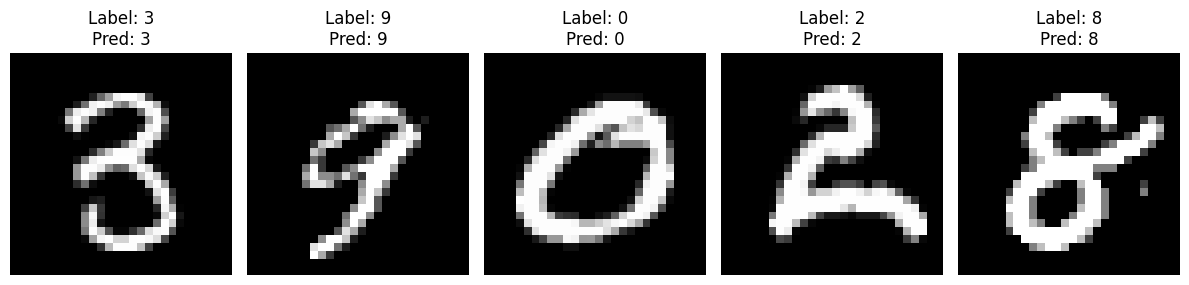

In [19]:

# Display images with predictions
plot_images(x_test_images[random_indices], true_classes[random_indices], prediction_classes[random_indices])

In [22]:
import tensorflow as tf
from tensorflow.keras.callbacks import TensorBoard

# Ensure TensorBoard package is installed for tf.summary support
try:
    import tensorboard
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tensorboard"])
    import tensorboard

Name = "MNIST-28-28-V1"
tensorboard = TensorBoard(log_dir=f"logs/{Name}")

# Load and preprocess the MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Preprocess data (normalize)
x_train = x_train.astype('float32') / 255.0#min -max scaler
x_test = x_test.astype('float32') / 255.0

# Flatten the images (28x28 -> 784)
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)
# One-hot encode labels
y_train_oh = tf.keras.utils.to_categorical(y_train, 10)
y_test_oh = tf.keras.utils.to_categorical(y_test, 10)

# Define a very simple model with inappropriate settings
model = tf.keras.Sequential([
    # Very few neurons and no hidden layers
    tf.keras.layers.Dense(500, activation='tanh', input_shape=(784,)),
    tf.keras.layers.Dense(10, activation='softmax')
    # Output layer for classification
])
model.summary()
# Compile the model with an extremely high learning rate
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.5),  # High learning rate
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train for very few epochs
history = model.fit(x_train, y_train_oh, epochs=10, batch_size=64, validation_split=0.2, callbacks=[tensorboard])

# Evaluate the model on the test data
test_loss, test_acc = model.evaluate(x_test, y_test_oh)
print(f"Test accuracy: {test_acc}")

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 500)            │       392,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 397,510 (1.52 MB)

 Trainable params: 397,510 (1.52 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.6166 - loss: 19.4337 - val_accuracy: 0.6758 - val_loss: 11.6971
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.6565 - loss: 18.3677 - val_accuracy: 0.7112 - val_loss: 18.3049
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.6768 - loss: 19.2194 - val_accuracy: 0.6658 - val_loss: 17.2814
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.7111 - loss: 18.1538 - val_accuracy: 0.6957 - val_loss: 21.1450
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7049 - loss: 18.3432 - val_accuracy: 0.7217 - val_loss: 19.9608
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.7264 - loss: 19.1489 - val_accuracy: 0.7394 - val_loss: 19.3167
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7383 - loss: 19.0663 - val_accuracy: 0.7081 - val_loss: 23.8814
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7420 - loss: 20.212

In [28]:
!tensorboard --logdir=logs --port=6006

'tensorboard' is not recognized as an internal or external command,
operable program or batch file.
